<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# Portfolio Project: Model Evaluation and Refinement - Laptop Pricing Model
**IBM Data Science Professional Certificate | Module 5: Model Evaluation and Refinement**

### 👨‍💻 Executive Summary
This notebook documents the process required to evaluate models for laptop prices. By using cross validation to improve the model, testing for overfitting, plotting the resulting R-squared values for polynomials of different orders, using Ridge Regression, and Grid Search, this lab shows all the necessary steps taken to properly evaluate and refine a model. 

---
*Original lab framework provided by IBM Skills Network. Technical implementation, 
statistical analysis, and model interpretation performed by [Roberto Castro/rcastro-ai](https://github.com/rcastro-ai)*

# **Hands-on Practice Lab: Model Evaluation and Refinement**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired throughout the module, and try to refine your model's performance in predicting the price of a laptop, given the attribute values.


# Objectives

After completing this lab you will be able to:

 - Use training, testing and cross validation to improve the performance of the dataset. 
 - Identify the point of overfitting of a model
 - Use Ridge Regression to identify the change in performance of a model based on its hyperparameters
 - Use Grid Search to identify the best performing model using different hyperparameters


# Setup


For this lab, we will be using the following libraries:

* `skillsnetwork` for downloading the dataset
*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Installing Required Libraries

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `%pip` in the code cell below.


The following required libraries are __not__ pre-installed in the Skills Network Labs environment. __You will need to run the following cell__ to install them:


In [1]:
# Importing needed library (if working on a browser)

#import piplite
#await piplite.install('seaborn')

### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [2]:
# Importing needed libraries

from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

# Importing the Dataset

Run the cell below to donwload the dataset into the console.


In [3]:
# Uncomment if working on a browser

#from pyodide.http import pyfetch

# Method to download a file (when running on a browser)

#async def download(url, filename):
#    response = await pyfetch(url)
#    if response.status == 200:
#        with open(filename, "wb") as f:
#            f.write(await response.bytes())

In [4]:
# Setting the values for filepath and filename

filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/laptop_pricing_dataset_mod2.csv'
filename = "laptops_C7M5.csv"

In [5]:
# Downloading the file (if working on a browser)

#await download(filepath, filename)

> Note: This version of the lab is working on JupyterLite, which requires the dataset to be downloaded to the interface.While working on the downloaded version of this notebook on their local machines(Jupyter Anaconda), the learners can simply **skip the steps above,** and simply use the URL directly in the `pandas.read_csv()` function. You can uncomment and run the statements in the cell below.


Import the data set into a data frame.


In [6]:
# Loading the data into dataframe df (if working on a browser)

#df = pd.read_csv(filename, header=0) # File has headers in row 0

In [7]:
# If working locally run this cell

df = pd.read_csv(filepath, header=0)

In [8]:
# Saving the original file locally 

#df.to_csv(filename)

Print the value of df.head(). 


In [9]:
# Browsing the first 5 rows of the dataframe

df.head()

,Unnamed: 0.1,Unnamed: 0,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,0,0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,1,1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,2,2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,3,3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,4,4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


Drop the two unnecessary columns that have been added into the file, 'Unnamed: 0' and 'Unnamed: 0.1'. Use drop to delete these columns.


In [10]:
# Dropping columns 'Unnamed: 0' and 'Unnamed: 0.1' as they are not needed for the model

df.drop(['Unnamed: 0', 'Unnamed: 0.1'], axis=1, inplace=True)

In [11]:
# Showing the 5 first rows after dropping the two columns above

df.head()

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


# Task 1 : Using Cross validation to improve the model

Divide the dataset into x_data and y_data parameters. Here y_data is the "Price" attribute, and x_data has all other attributes in the data set.


In [12]:
# Dividing the dataset into x_data (predictor variables) and y_data for 'Price' (target variable)

# Creating series y_data to hold values for target variable 'Price'
y_data = df['Price']

# Create dataframe x_data without the column 'Proce'
x_data = df.drop('Price', axis=1)

<details><summary>Click here for the solution</summary>

```python
y_data = df['Price']
x_data = df.drop('Price',axis=1)
```

</details>


Split the data set into training and testing subests such that you reserve 10% of the data set for testing purposes.


In [13]:
# Splitting the data into training data and testing data

x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1) # 10% of the dataset will be for test data

# Showing the size of each sample after the split
print("Number of training samples:", x_train.shape[0])
print("Number of test samples :", x_test.shape[0])


Number of training samples: 214
Number of test samples : 24


<details><summary>Click here for the solution</summary>

```python
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.10, random_state=1)
print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])
```

</details>


Create a single variable linear regression model using "CPU_frequency" parameter. Print the R^2 value of this model for the training and testing subsets.


In [14]:
# Creating a SLR model using feature 'CPU_frequency'

# Creating linear regression object
lr = LinearRegression()

# Fitting the model using the feature 'CPU_frequency'
lr.fit(x_train[['CPU_frequency']], y_train)

# Getting R-squared on the training data
r_squared_train = lr.score(x_train[['CPU_frequency']], y_train)

# Getting R-squared on the test data
r_squared_test = lr.score(x_test[['CPU_frequency']], y_test)

# Printing R-squared values
print('R-squared for training data is: ', r_squared_train)
print('R-squared for test data is: ', r_squared_test)

R-squared for training data is:  0.14829792099817973
R-squared for test data is:  -0.06599437350393766


<details><summary>Click here for the solution</summary>

```python
lre=LinearRegression()
lre.fit(x_train[['CPU_frequency']], y_train)
print(lre.score(x_test[['CPU_frequency']], y_test))
print(lre.score(x_train[['CPU_frequency']], y_train))
```

</details>


Run a 4-fold cross validation on the model and print the mean value of R^2 score along with its standard deviation.


In [15]:
# Running a 4-fold cross validation on the model

# Calculating the cross validation score
Rcross = cross_val_score(lr, x_train[['CPU_frequency']], y_train, cv=4)

# Getting mean value of r_squared and standard deviation
cv_r_quared_mean = Rcross.mean()
cv_std = Rcross.std()

# Printing the mean of the R-squared values and the standard deviation
print('The mean value of R-squared is: ', cv_r_quared_mean)
print('The standard deviation is: ', cv_std)

The mean value of R-squared is:  0.12738818019555026
The standard deviation is:  0.0831705801091202


<details><summary>Click here for the solution</summary>

```python
Rcross = cross_val_score(lre, x_train[['CPU_frequency']], y_data, cv=4)
print("The mean of the folds are", Rcross.mean(), "and the standard deviation is" , Rcross.std())
```

</details>


# Task 2: Overfitting

Split the data set into training and testing components again, this time reserving 50% of the data set for testing.


In [16]:
# Spliting the original dataset into training and test data sets using 50% of the data for each

x_train_1, x_test_1, y_train_1, y_test_1 = train_test_split(x_data, y_data, test_size=0.5, random_state=1) # 50% of the dataset will be for test data

# Showing the size of each sample after the split
print("Number of training samples:", x_train_1.shape[0])
print("Number of test samples :", x_test_1.shape[0])


Number of training samples: 119
Number of test samples : 119


<details><summary>Click here for the solution</summary>

```python
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.5, random_state=0)
# fixing random_state to a fixed quantity helps maintain uniformity between multiple 
# executions of the code.
```

</details>


To identify the point of overfitting the model on the parameter "CPU_frequency", you'll need to create polynomial features using the single attribute. 
You need to evaluate the R^2 scores of the model created using different degrees of polynomial features, ranging from 1 to 5. Save this set of values of R^2 score as a list.


In [17]:
# Creating polynomial features to identify the point of overfitting for a model using one parameter: 'CPU_frequency'

# Importing needed library
from IPython.display import display

# Using a 5th degree polynomial with feature 'CPU_frequency'
pr = PolynomialFeatures(degree=5)
x_train_pr_1 = pr.fit_transform(x_train_1[['CPU_frequency']])

# Using transform without fit for test data
#x_test_pr_1 = pr.fit_transform(x_test_1[['CPU_frequency']])
x_test_pr_1 = pr.transform(x_test_1[['CPU_frequency']])

# Testing the model for five different order ploynomials

# Creating linear regression object
lr_1 = LinearRegression()

# Defining the list that will hold the scores for the different iterations
r_squared_test = []

# List ontaining the orders to test
order = [1, 2, 3, 4, 5]

for n in order:
    poly = PolynomialFeatures(degree=n)
    
    x_train_pr_1 = poly.fit_transform(x_train_1[['CPU_frequency']])
    # Using transform without fit for test data
    #x_test_pr_1 = poly.fit_transform(x_test_1[['CPU_frequency']])    
    x_test_pr_1 = poly.transform(x_test_1[['CPU_frequency']])    
    
    lr_1.fit(x_train_pr_1, y_train_1)
    
    r_squared_test.append(lr_1.score(x_test_pr_1, y_test_1))

# Generating the output

# Creating a dictionary to organize the data
results_dict = {
    'Polynomial Order': order,
    'R-squared Score': r_squared_test
}

# Converting to a DataFrame
results_df = pd.DataFrame(results_dict)

# Displaying the table
print("--- Polynomial Order vs. R-squared Performance ---\n")
display(results_df)


--- Polynomial Order vs. R-squared Performance ---



,Polynomial Order,R-squared Score
0,1,0.028619
1,2,0.145209
2,3,0.156816
3,4,0.127213
4,5,0.035471


<details><summary>Click here for the solution</summary>

```python
lre = LinearRegression()
Rsqu_test = []
order = [1, 2, 3, 4, 5]
for n in order:
    pr = PolynomialFeatures(degree=n)
    x_train_pr = pr.fit_transform(x_train[['CPU_frequency']])
    x_test_pr = pr.fit_transform(x_test[['CPU_frequency']])    
    lre.fit(x_train_pr, y_train)
    Rsqu_test.append(lre.score(x_test_pr, y_test))
```

</details>


Plot the values of R^2 scores against the order. Note the point where the score drops.


Text(0.5, 1.0, 'R^2 Using Test Data')

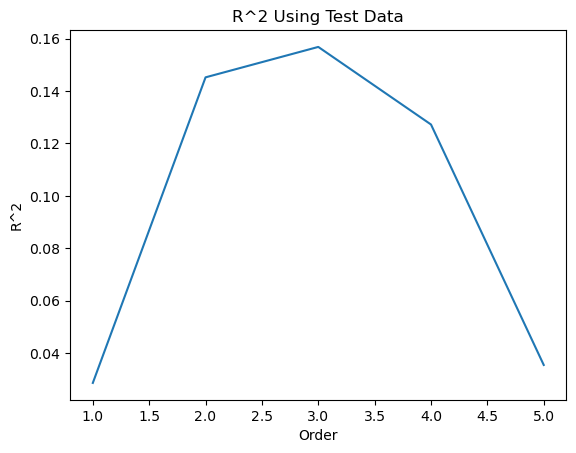

In [18]:
# Plotting the values of R-squared

plt.plot(order, r_squared_test)
plt.xlabel('Order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')


**Note:** Based on the plot above, the order of the polynomial with the best score is **3**. For orders larger than 3, R-squared drops.

<details><summary>Click here for the solution</summary>

```python
plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')
```

</details>


# Task 3 : Ridge Regression

Now consider that you have multiple features, i.e. 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU' and 'Category'. Create a polynomial feature model that uses all these parameters with degree=2. Also create the training and testing attribute sets.


In [19]:
# Creating a model with multiple features: 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU' and 'Category'

# Spliting the original dataset into training and test data sets using 30% for test data
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_data, y_data, test_size=0.3, random_state=1) # 30% of the dataset will be for test data

# Performing a degree two polynomial transformation

pr_2 = PolynomialFeatures(degree=2)
x_train_pr_2 = pr.fit_transform(x_train_2[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']])

# Using transform without fit for test data
#x_test_pr_2 = pr.fit_transform(x_test_2[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']])
x_test_pr_2 = pr.transform(x_test_2[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']])

# Showing the size of each sample after the split
print("Number of training samples:", x_train_2.shape[0])
print("Number of test samples :", x_test_2.shape[0])


Number of training samples: 166
Number of test samples : 72


<details><summary>Click here for the solution</summary>

```python
pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']])
x_test_pr=pr.fit_transform(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']])
```

</details>


Create a Ridge Regression model and evaluate it using values of the hyperparameter alpha ranging from 0.001 to 1 with increments of 0.001. 
Create a list of all Ridge Regression R^2 scores for training and testing data. 


In [20]:
# Generating the value of the scores for different values of alpha (from 0.001 to 1 with increments of 0.001)

# Ignoring warnings 
import warnings
warnings.filterwarnings('ignore')

# Creating lists to hold values of the scores
r_squared_test = []
r_squared_train = []

# Creating am array for all the values of alpha that will be tested
Alpha = np.array(range(1, 1001)) / 1000

print("Starting Ridge Alpha Tuning...\n")

for i, alpha in enumerate(Alpha):
    RidgeModel = Ridge(alpha=alpha) 
    RidgeModel.fit(x_train_pr_2, y_train_2)

    train_score = RidgeModel.score(x_train_pr_2, y_train_2)
    test_score = RidgeModel.score(x_test_pr_2, y_test_2)
    
    # Store scores
    r_squared_train.append(train_score)
    r_squared_test.append(test_score)

    # Only print every 100 iterations to avoid the "wall of text"
    if (i + 1) % 100 == 0:
        print(f"Iteration {i + 1}/1000 | Current Alpha: {alpha:.3f}")
    

Starting Ridge Alpha Tuning...

Iteration 100/1000 | Current Alpha: 0.100
Iteration 200/1000 | Current Alpha: 0.200
Iteration 300/1000 | Current Alpha: 0.300
Iteration 400/1000 | Current Alpha: 0.400
Iteration 500/1000 | Current Alpha: 0.500
Iteration 600/1000 | Current Alpha: 0.600
Iteration 700/1000 | Current Alpha: 0.700
Iteration 800/1000 | Current Alpha: 0.800
Iteration 900/1000 | Current Alpha: 0.900
Iteration 1000/1000 | Current Alpha: 1.000


<details><summary>Click here for the solution</summary>

```python
Rsqu_test = []
Rsqu_train = []
Alpha = np.arange(0.001,1,0.001)
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha) 
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)
    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})
    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)
```

</details>


Plot the R^2 values for training and testing sets with respect to the value of alpha


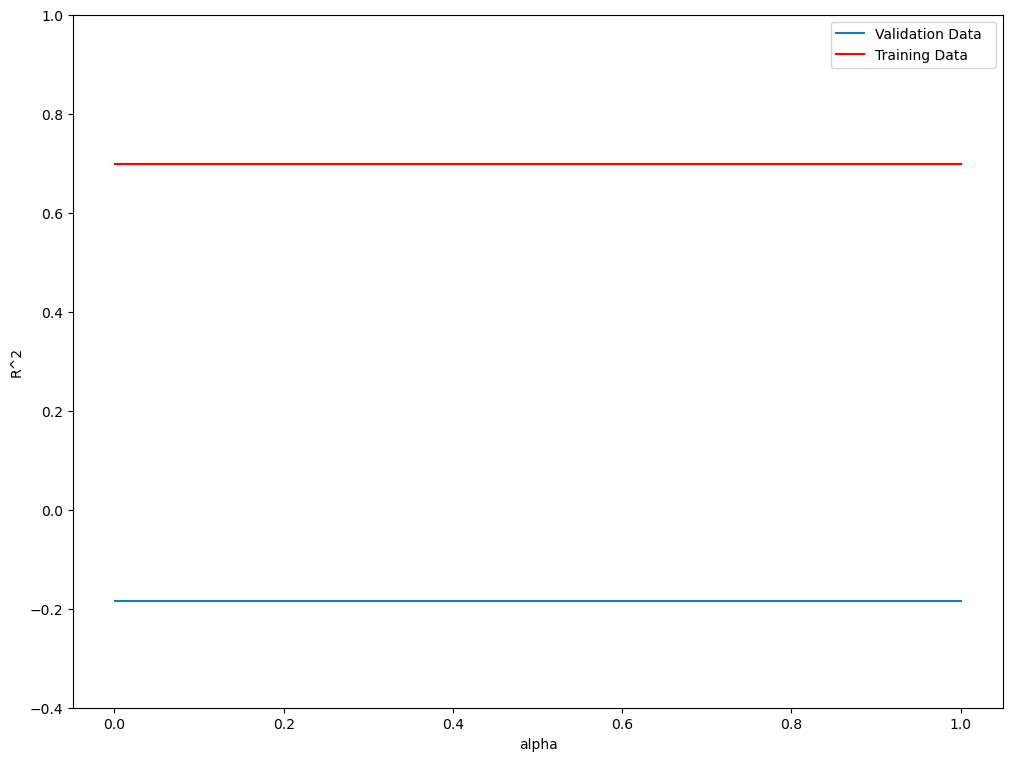

In [21]:
# Plotting the values of R-squared for different values of alpha

width = 12
height = 9
plt.figure(figsize=(width, height))

plt.plot(Alpha, r_squared_test, label='Validation Data  ')
plt.plot(Alpha, r_squared_train, 'r', label='Training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.ylim(-0.4, 1)
plt.legend()


<details><summary>Click here for the solution</summary>

```python
plt.figure(figsize=(10, 6))  
plt.plot(Alpha, Rsqu_test, label='validation data')
plt.plot(Alpha, Rsqu_train, 'r', label='training Data')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.ylim(0, 1)
plt.legend()
```

</details>


# Task 4: Grid Search

Using the raw data and the same set of features as used above, use GridSearchCV to identify the value of alpha for which the model performs best. 
Assume the set of alpha values to be used as
```math
{0.0001, 0.001, 0.01, 0.1, 1, 10}
```


In [22]:
# Creating a dictionary with parameter values for alpha

parameters = [{'alpha': [0.0001, 0.001, .01, 0.1, 1, 10]}]

parameters

[{'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]}]

<details><summary>Click here for the solution</summary>

```python
parameters1= [{'alpha': [0.0001,0.001,0.01, 0.1, 1, 10]}]
```

</details>


Create a Ridge instance and run Grid Search using a 4 fold cross validation.


In [23]:
# Using Grid Search to find the best performing model

# Creating a Ridge regression object
RR = Ridge()

# Creating a Grid Search object
Grid_search = GridSearchCV(RR, parameters, cv=4)


<details><summary>Click here for the solution</summary>

```python
RR=Ridge()
Grid1 = GridSearchCV(RR, parameters1,cv=4)
```
</details>


Fit the Grid Search to the training data.


In [24]:
# Fitting the model

Grid_search.fit(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']], y_train)


,estimator,Ridge()
,param_grid,"[{'alpha': [0.0001, 0.001, ...]}]"
,scoring,None
,n_jobs,None
,refit,True
,cv,4
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,0.1


<details><summary>Click here for the solution</summary>

```python
Grid1.fit(x_train[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']], y_train)
```
</details>


Print the R^2 score for the test data using the estimator that uses the derived optimum value of alpha.


In [25]:
# Obtaining the best R-squared value for the optimal alpha

# Obtaining the best parameter value
best_estimator = Grid_search.best_estimator_

# Testing the model using the test data

best_r_squared = best_estimator.score(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']], y_test)
best_alpha = best_estimator.alpha

# Printing R-squared
print('R-squared for best alpha: ', best_r_squared)
print('Best alpha value: ', best_alpha)
print('')

# Showing which features the model thinks are most important
features = ['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU', 'Category']
coeffs = pd.DataFrame({'Feature': features, 'Coefficient': best_estimator.coef_})
print(coeffs.sort_values(by='Coefficient', ascending=False))

R-squared for best alpha:  0.24478039817907105
Best alpha value:  0.1

          Feature  Coefficient
0   CPU_frequency   980.592769
6        Category   172.648428
3        CPU_core    88.721463
1          RAM_GB    83.346940
5             GPU    78.484005
2  Storage_GB_SSD     0.038991
4              OS  -441.002776


<details><summary>Click here for the solution</summary>

```python
BestRR=Grid1.best_estimator_
print(BestRR.score(x_test[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core','OS','GPU','Category']], y_test))
```
</details>


# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


Copyright © 2023 IBM Corporation. All rights reserved.


<!--## Change Log


<!--|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2023-09-16|0.1|Abhishek Gagneja|Initial Version Created|
|2023-09-19|0.2|Vicky Kuo|Reviewed and Revised|
--!>
